## Imports

In [469]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load in images

In [470]:
gear = cv2.imread("trybik.jpg")
gears = cv2.imread("trybiki2.jpg")

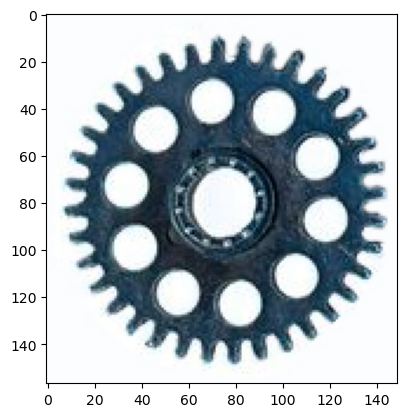

In [471]:
plt.imshow(gear)

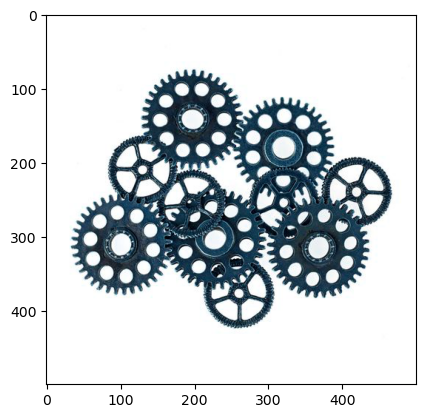

In [472]:
plt.imshow(gears)

## R-Table

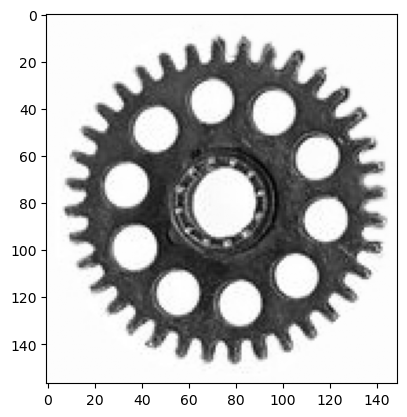

In [473]:
gray_gear = cv2.cvtColor(gear, cv2.COLOR_BGR2GRAY)
plt.gray()
plt.imshow(gray_gear)

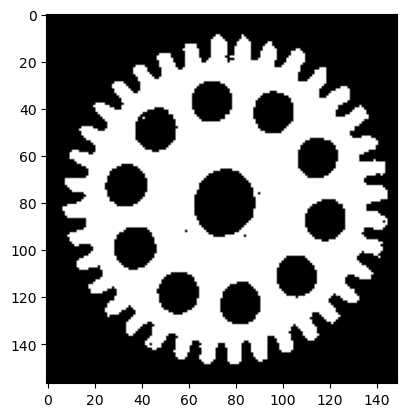

In [474]:
ret, gear_thresh = cv2.threshold(gray_gear, 230, 255, cv2.THRESH_BINARY)
#gear_thresh = cv2.morphologyEx(gear_thresh, cv2.MORPH_OPEN, np.ones((5, 5)))
gear_thresh = cv2.bitwise_not(gear_thresh)

plt.imshow(gear_thresh)

In [475]:
contours, hierarchy = cv2.findContours(gear_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

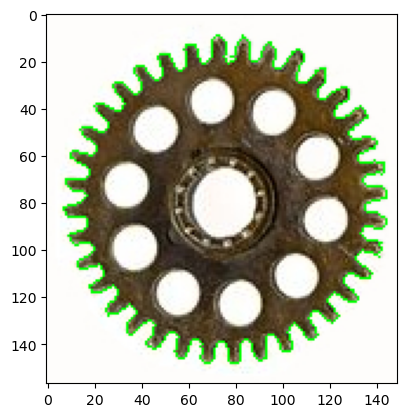

In [476]:
plotted_contours = cv2.drawContours(cv2.cvtColor(gear, cv2.COLOR_BGR2RGB), contours, -1, (0, 255, 0))
plt.imshow(plotted_contours)

In [477]:
gx = cv2.Sobel(gear_thresh, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gear_thresh, cv2.CV_64F, 0, 1, ksize=3)

magnitude, orientation_deg = cv2.cartToPolar(gx, gy, angleInDegrees=True)

In [478]:
M = cv2.moments(gear_thresh, binaryImage=True)

area = M["m00"]

cx = int(M["m10"] / M["m00"])
cy = int(M["m01"] / M["m00"])

In [479]:
r_table = [[] for _ in range(360)]

for cnt in contours:
    for point in cnt:
        x, y = point[0]
        
        phi = int(np.round(orientation_deg[y, x])) % 360
        
        dx = cx - x
        dy = cy - y
        
        r = np.sqrt(dx**2 + dy**2)
        
        alpha = np.degrees(np.arctan2(dy, dx)) % 360
        
        r_table[phi].append((r, alpha))

## Results

In [480]:
test_img = cv2.imread("trybiki2.jpg", cv2.IMREAD_GRAYSCALE)
h, w = test_img.shape

accumulator = np.zeros((h, w), dtype=np.float32)

In [481]:
gx_test = cv2.Sobel(test_img, cv2.CV_64F, 1, 0, ksize=3)
gy_test = cv2.Sobel(test_img, cv2.CV_64F, 0, 1, ksize=3)

mag_test, angle_test = cv2.cartToPolar(gx_test, gy_test, angleInDegrees=True)

mag_max = np.max(mag_test)
if mag_max > 0:
    mag_norm = mag_test / mag_max
else:
    mag_norm = mag_test

In [482]:
for y in range(h):
    for x in range(w):
        if mag_norm[y, x] > 0.5:
            phi = int(np.round(angle_test[y, x])) % 360
            
            for r, alpha in r_table[phi]:
                alpha_rad = np.radians(alpha)
                
                x1 = int(round(x - r * np.cos(alpha_rad)))
                y1 = int(round(y - r * np.sin(alpha_rad)))
                
                if 0 <= x1 < w and 0 <= y1 < h:
                    accumulator[y1, x1] += 1

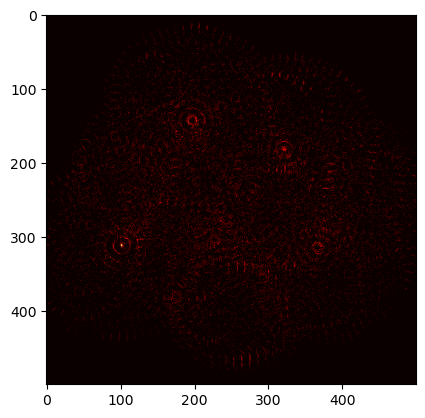

In [483]:
acc_vis = cv2.normalize(accumulator, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

_, max_val, _, max_loc = cv2.minMaxLoc(accumulator)

plt.imshow(acc_vis, cmap="hot")

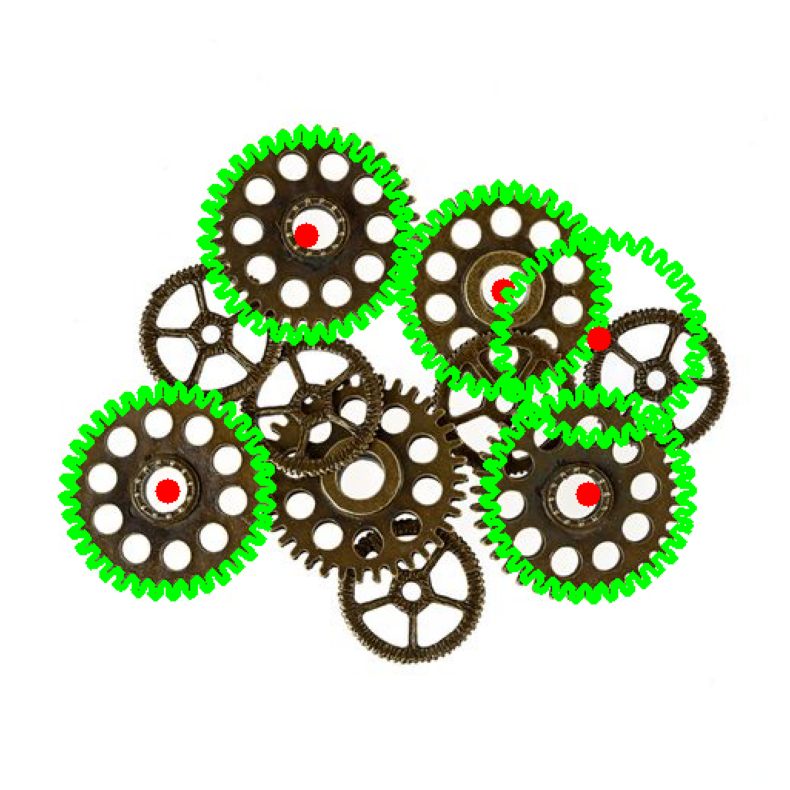

In [484]:
res_img = cv2.cvtColor(gears, cv2.COLOR_BGR2RGB)
acc_copy = accumulator.copy()

pattern_contour = max(contours, key=len) 
pattern_points = pattern_contour.reshape(-1, 2)

pattern_centered = pattern_points - [cx, cy]

for i in range(5):
    _, max_val, _, max_loc = cv2.minMaxLoc(acc_copy)
    tx, ty = max_loc

    cv2.circle(res_img, (tx, ty), 8, (255, 0, 0), -1)

    shifted_contour = pattern_centered + [tx, ty]

    final_cnt = shifted_contour.astype(np.int32).reshape((-1, 1, 2))
    cv2.drawContours(res_img, [final_cnt], -1, (0, 255, 0), 3)
    cv2.circle(acc_copy, (tx, ty), 50, 0, -1)

plt.figure(figsize=(12, 10))
plt.imshow(res_img)
plt.axis("off")
plt.show()